# Лабораторная работа 1. Описательные статистики

Загрузите датасет players.csv из папки datasets

# Задание 1
Для каждого признака посчитайте следующие описательные статистики:

1. Среднее

2. Медиана

3. Стандартное отклонение

4. Коэффициента ассиметрии и эксцесса

5. Межквартильный размах

6. Процентили 5% и 95%

Произведите анализ полученных статистик

In [14]:
#1
import pandas as pd
from scipy.stats import iqr

df = pd.read_csv('players.csv')
mean_values = df.mean(numeric_only=True)
print(mean_values, "\n")

#2
medians = df.median(numeric_only=True)
print(medians, "\n")

#3
std_deviation = df.std()
print(std_deviation, "\n")

#4
skewness = df.skew(numeric_only=True)
kurtosis = df.kurtosis(numeric_only=True)

metrics_df = pd.DataFrame({
    'Асимметрия (Skewness)': skewness,
    'Эксцесс (Kurtosis)': kurtosis
})

print(metrics_df, "\n")

#5
numeric_df = df.select_dtypes(include=['number'])

q1 = numeric_df.quantile(0.25)
q3 = numeric_df.quantile(0.75)

iqr = q3 - q1

print(iqr, "\n")

#6
percentiles = df.quantile([0.05, 0.95], numeric_only=True)

print(percentiles, "\n")

sofifa_id    2.314681e+05
overall      6.577218e+01
value_eur    2.850452e+06
wage_eur     9.017989e+03
age          2.521082e+01
height_cm    1.812997e+02
weight_kg    7.494303e+01
dtype: float64 

sofifa_id    236543.0
overall          66.0
value_eur    975000.0
wage_eur       3000.0
age              25.0
height_cm       181.0
weight_kg        75.0
dtype: float64 

sofifa_id    2.703972e+04
overall      6.880232e+00
value_eur    7.613700e+06
wage_eur     1.947018e+04
age          4.748235e+00
height_cm    6.863179e+00
weight_kg    7.069434e+00
dtype: float64 

           Асимметрия (Skewness)  Эксцесс (Kurtosis)
sofifa_id              -1.460740            5.385233
overall                 0.081602            0.091004
value_eur               8.186343           97.897519
wage_eur                6.472150           63.067340
age                     0.431183           -0.413828
height_cm              -0.039905           -0.325940
weight_kg               0.242040            0.056305 

sofif

# Задание 2
Для каждого признака нарисуйте следующие графики:

1. Гистограмма с плотностью распределения

2. Ящик с усами

Что можно сказать глядя на эти графики?

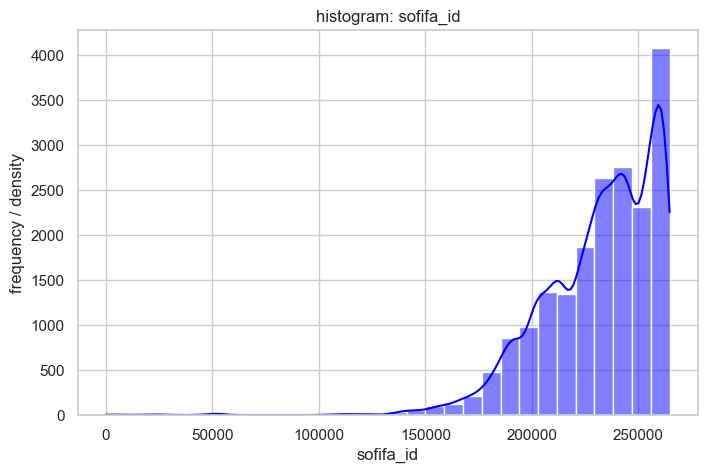

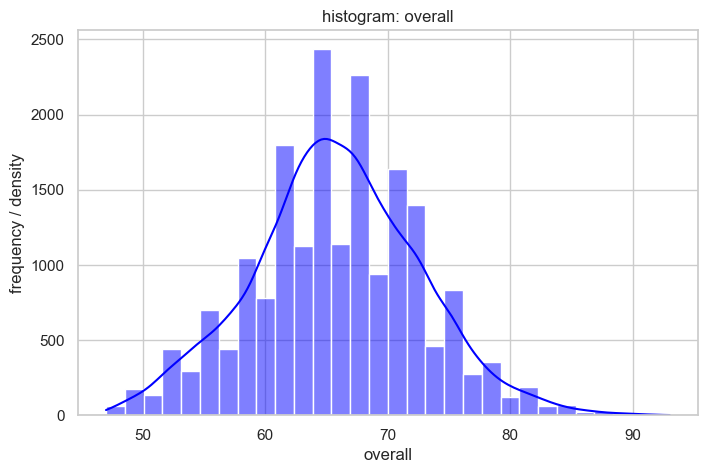

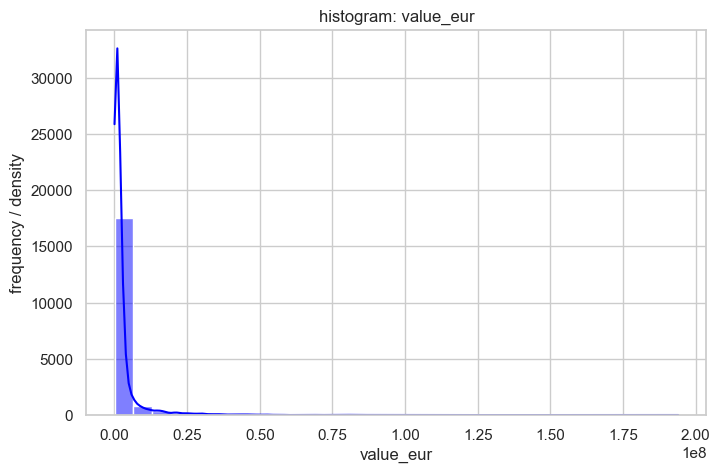

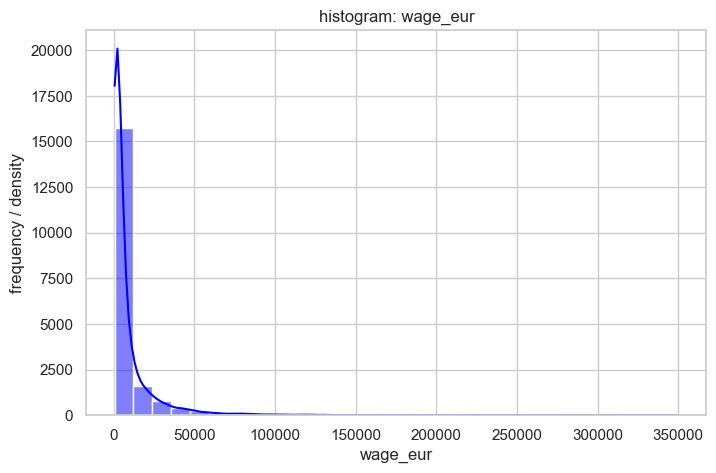

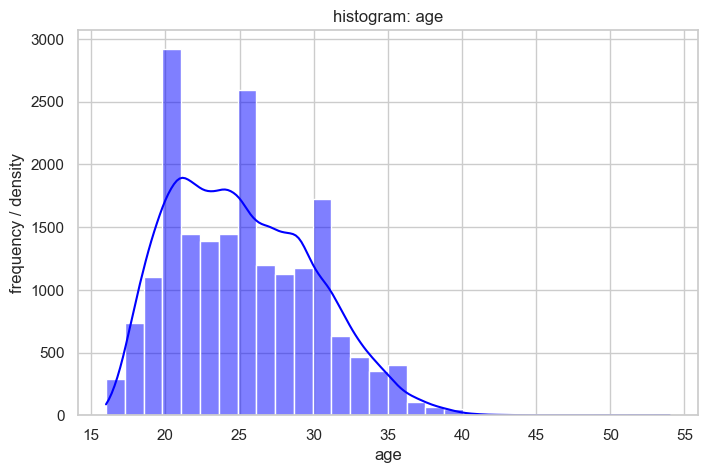

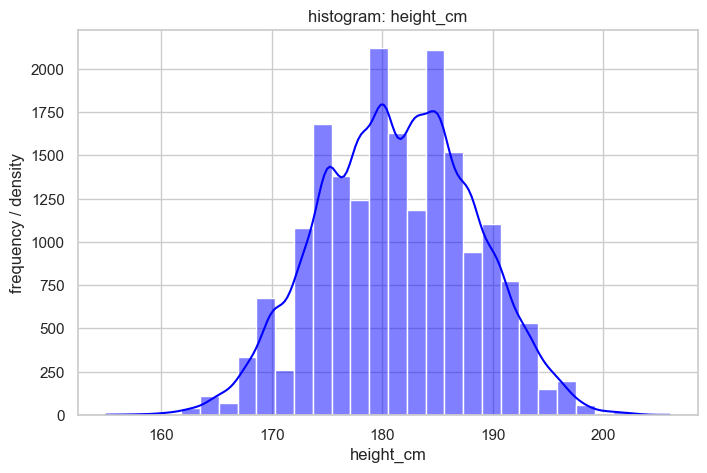

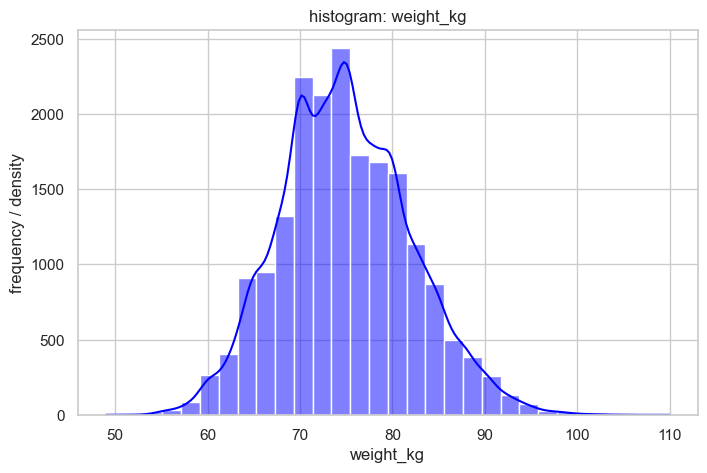

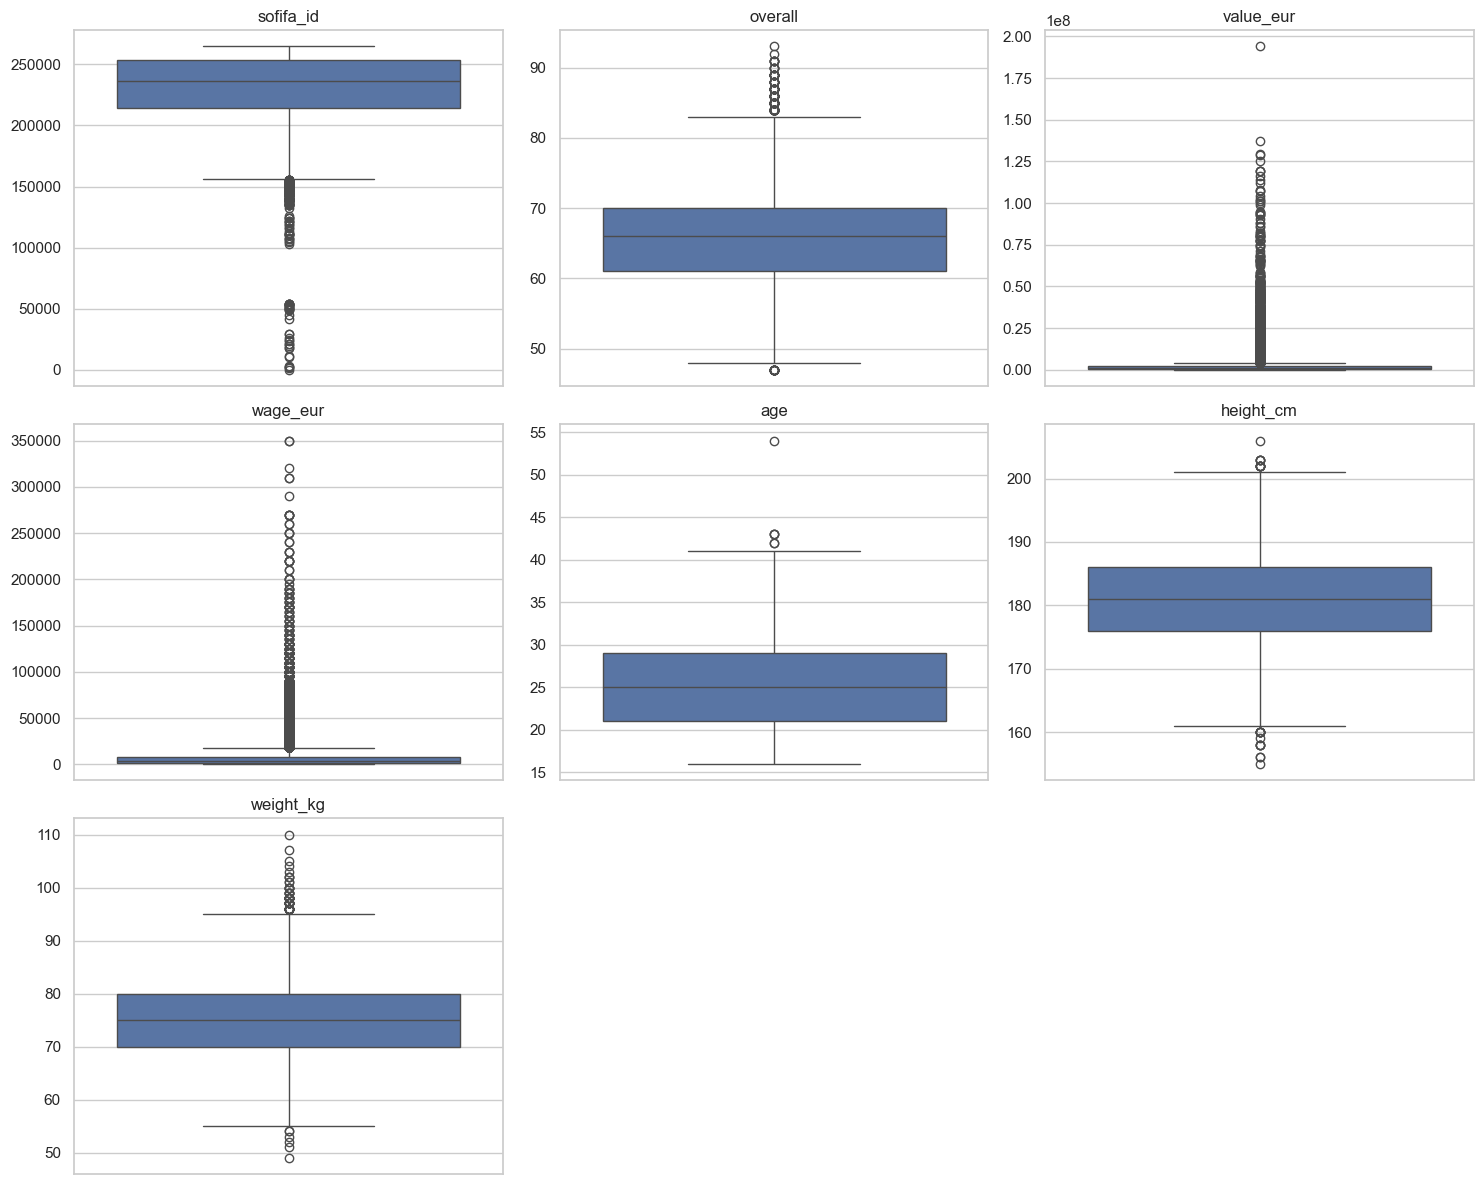

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

#1
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

sns.set_theme(style='whitegrid')

for col in numeric_cols:
  plt.figure(figsize=(8, 5))

  sns.histplot(df[col], kde=True, color='blue', bins=30)

  plt.title(f'histogram: {col}')
  plt.xlabel(col)
  plt.ylabel('frequency / density')

  plt.show()

#2
num_cols_grid = 3
num_rows_grid = (len(numeric_cols) + num_cols_grid - 1) // num_cols_grid

fig, axes = plt.subplots(
    num_rows_grid, num_cols_grid, figsize=(5 * num_cols_grid, 4 * num_rows_grid)
)
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("") 

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Задание 3
Выберете признак, подозрительный на нормальное распределение. Для этого признака проверьте гитотезу об нормальном распределении на уровне значимости 0.05 используя как минимум 2 статистических теста. Нарисуйте график Q/Q плот.

Shapiro p-value: 2.105302493793214e-22
D'Agostino p-value: 1.7449648542128465e-28


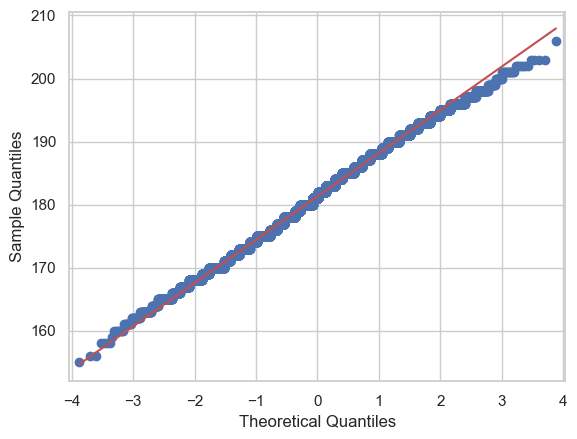

In [25]:
#3 height
import scipy.stats as stats
import statsmodels.api as sm

data = df["height_cm"].dropna()

print("Shapiro p-value:", stats.shapiro(data)[1])
print("D'Agostino p-value:", stats.normaltest(data)[1])

sm.qqplot(data, line="s")
plt.show()
